# Sunburn Cases vs UV Index: A Statistical Assessment

This notebook provides a comprehensive analysis of the relationship between UV Index and emergency department sunburn/heat-stroke cases in England. We analyze UK Health Security Agency (UKHSA) data to determine the core relationship between UV exposure and sunburn cases.

## Key Objectives
1. Explore the temporal patterns of UV index and sunburn cases
2. Visualize the relationship through multiple detailed graphs
3. Perform hypothesis testing to statistically validate the UV-sunburn relationship
4. Accept or reject hypotheses about causal and predictive relationships

## 1. Setup and Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway, kruskal
import statsmodels.api as sm
from statsmodels.tsa.stattools import ccf, grangercausalitytests
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Get project root
project_root = Path.cwd()
print(f"Project root: {project_root}")
print("Libraries loaded successfully!")

Project root: c:\Users\PC\Documents\code\uv-index\Project-UV
Libraries loaded successfully!


In [2]:
# Load the weekly aggregated data (from UK sunburns analysis)
weekly_data_path = project_root / 'tmp' / 'uk_sunburns' / 'data' / 'weekly_aggregated_data.csv'
df = pd.read_csv(weekly_data_path)

# Parse the week period string to get start date
df['week_start'] = pd.to_datetime(df['year_week'].str.split('/').str[0])
df['month'] = df['week_start'].dt.month
df['month_name'] = df['week_start'].dt.strftime('%B')
df['year'] = df['week_start'].dt.year
df['season'] = df['month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else 
                                           'Spring' if x in [3, 4, 5] else 
                                           'Summer' if x in [6, 7, 8] else 'Autumn')

print(f"Data loaded: {len(df)} weeks")
print(f"Date range: {df['week_start'].min().strftime('%Y-%m-%d')} to {df['week_start'].max().strftime('%Y-%m-%d')}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Data loaded: 64 weeks
Date range: 2024-07-01 to 2025-09-15

Columns: ['year_week', 'total_cases', 'avg_daily_cases', 'days_count', 'avg_uv_index', 'max_uv_index', 'min_uv_index', 'week_start', 'month', 'month_name', 'year', 'season']


,year_week,total_cases,avg_daily_cases,days_count,avg_uv_index,max_uv_index,min_uv_index,week_start,month,month_name,year,season
0,2024-07-01/2024-07-07,0.0,0.000000,1,1.340000,1.34,1.34,2024-07-01,7,July,2024,Summer
1,2024-07-08/2024-07-14,5.0,0.714286,7,0.985714,1.19,0.77,2024-07-08,7,July,2024,Summer
2,2024-07-15/2024-07-21,35.0,5.000000,7,1.307143,1.73,0.87,2024-07-15,7,July,2024,Summer
3,2024-07-22/2024-07-28,10.0,1.428571,7,1.312857,1.51,0.93,2024-07-22,7,July,2024,Summer
4,2024-07-29/2024-08-04,50.0,7.142857,7,1.337143,1.63,0.90,2024-07-29,7,July,2024,Summer


## 2. Exploratory Data Analysis

In [3]:
# Summary statistics
print("="*70)
print("SUMMARY STATISTICS")
print("="*70)

print("\n📊 UV Index Statistics (Weekly Average):")
print(f"   Mean: {df['avg_uv_index'].mean():.3f}")
print(f"   Std:  {df['avg_uv_index'].std():.3f}")
print(f"   Min:  {df['avg_uv_index'].min():.3f}")
print(f"   Max:  {df['avg_uv_index'].max():.3f}")
print(f"   Median: {df['avg_uv_index'].median():.3f}")

print("\n🏥 Sunburn Cases Statistics (Weekly Total):")
print(f"   Mean: {df['total_cases'].mean():.2f}")
print(f"   Std:  {df['total_cases'].std():.2f}")
print(f"   Min:  {df['total_cases'].min():.0f}")
print(f"   Max:  {df['total_cases'].max():.0f}")
print(f"   Median: {df['total_cases'].median():.0f}")
print(f"   Total: {df['total_cases'].sum():.0f}")

print("\n📅 Seasonal Distribution of Cases:")
seasonal_stats = df.groupby('season')['total_cases'].agg(['sum', 'mean', 'count'])
print(seasonal_stats.to_string())

SUMMARY STATISTICS

📊 UV Index Statistics (Weekly Average):
   Mean: 0.749
   Std:  0.545
   Min:  0.040
   Max:  1.896
   Median: 0.801

🏥 Sunburn Cases Statistics (Weekly Total):
   Mean: 11.52
   Std:  19.44
   Min:  0
   Max:  97
   Median: 4
   Total: 737

📅 Seasonal Distribution of Cases:
          sum       mean  count
season                         
Autumn   53.0   3.312500     16
Spring  129.0   9.923077     13
Summer  537.0  24.409091     22
Winter   18.0   1.384615     13


## 3. Detailed Visualizations

### 3.1 Time Series: UV Index vs Sunburn Cases

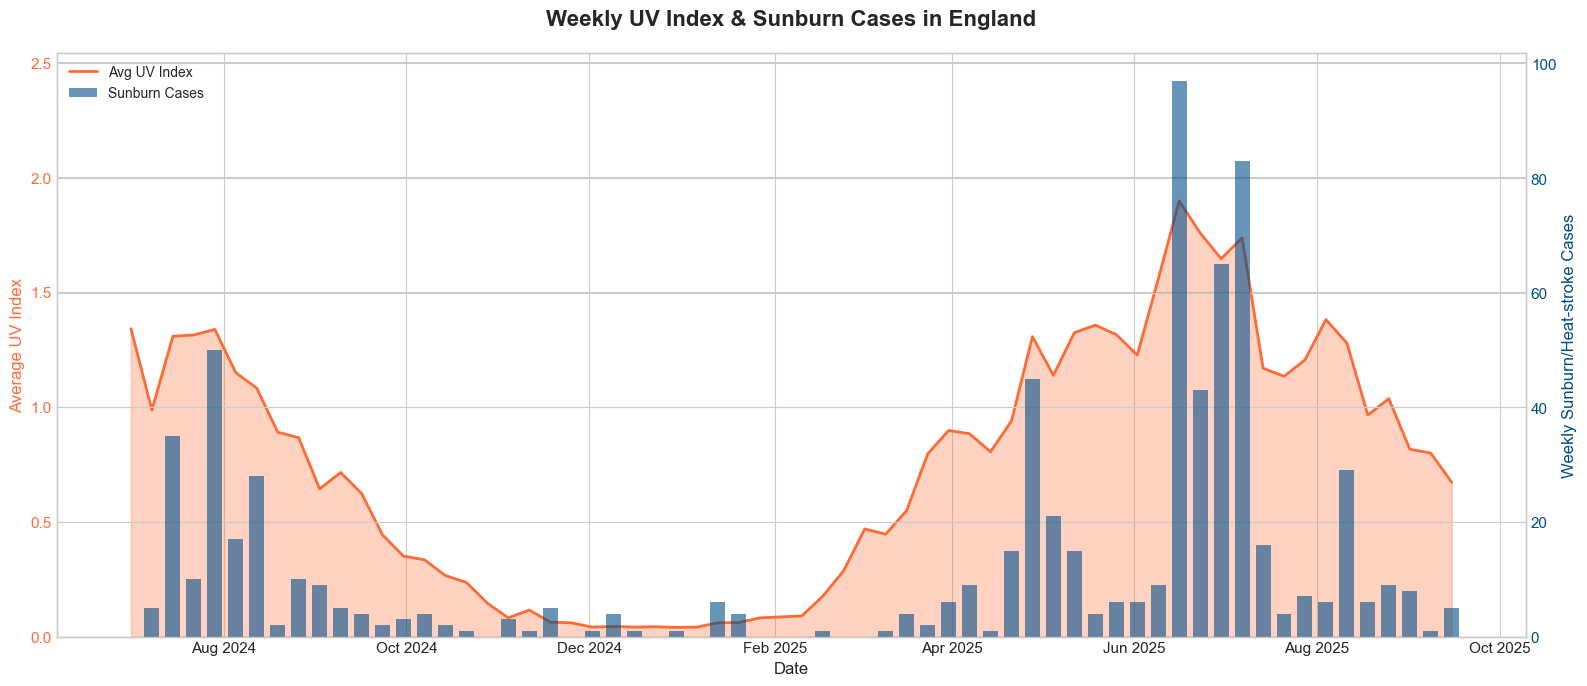


📈 Observation: Clear seasonal pattern - UV peaks in summer months correspond with sunburn case spikes.


In [ ]:
# Plot 1: Dual-Axis Time Series
fig, ax1 = plt.subplots(figsize=(16, 7))

# UV Index (left axis)
color_uv = '#FF6B35'
ax1.fill_between(df['week_start'], df['avg_uv_index'], alpha=0.3, color=color_uv)
ax1.plot(df['week_start'], df['avg_uv_index'], color=color_uv, linewidth=2, label='Avg UV Index')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Average UV Index', color=color_uv, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_uv)
ax1.set_ylim(0, df['max_uv_index'].max() * 1.1)

# Sunburn cases (right axis)
ax2 = ax1.twinx()
color_cases = '#004E89'
ax2.bar(df['week_start'], df['total_cases'], alpha=0.6, color=color_cases, width=5, label='Sunburn Cases')
ax2.set_ylabel('Weekly Sunburn/Heat-stroke Cases', color=color_cases, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_cases)

# Formatting
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.title('Weekly UV Index & Sunburn Cases in England', fontsize=16, fontweight='bold', pad=20)
fig.tight_layout()

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.savefig(project_root / 'output' / 'sunburn_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Correlation Scatter Plot with Regression

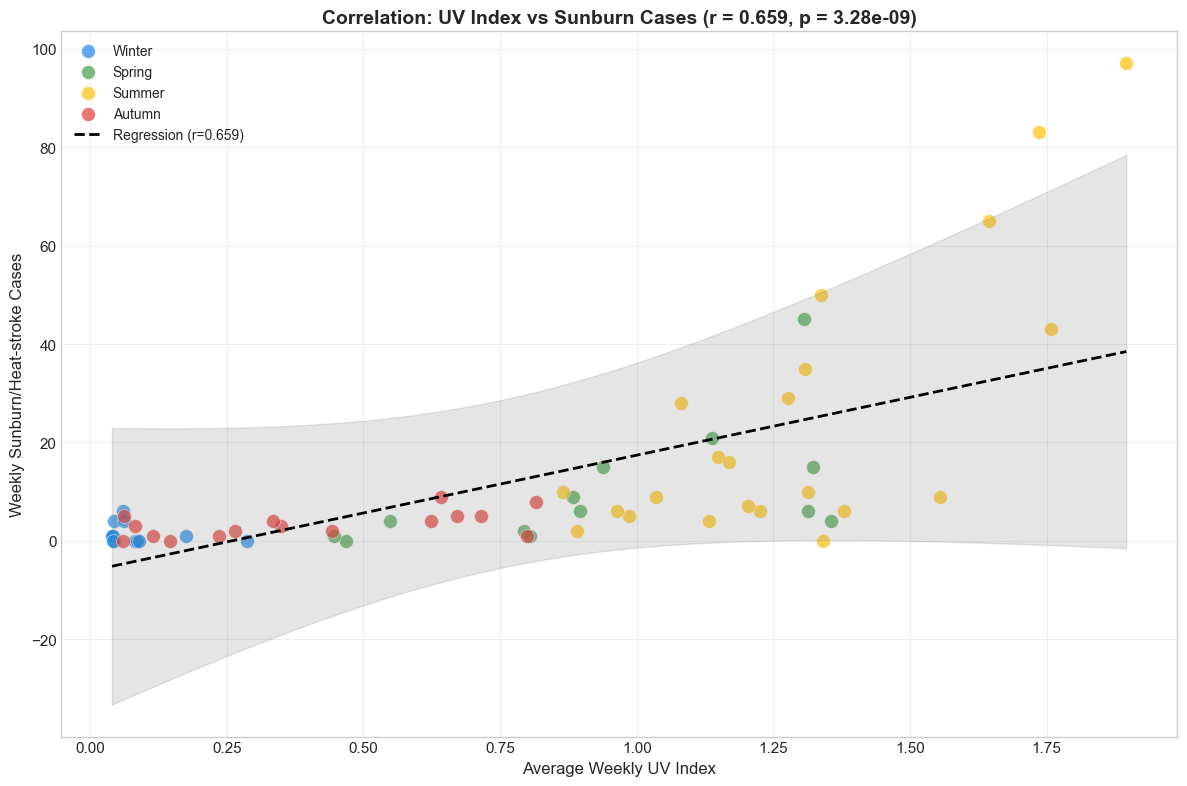


📊 Pearson correlation: r = 0.6587, p-value = 3.28e-09
   R² = 0.4339 (43.4% of variance explained)


In [5]:
# Plot 2: Scatter plot with regression line
fig, ax = plt.subplots(figsize=(12, 8))

# Calculate regression
slope, intercept, r_value, p_value, std_err = stats.linregress(df['avg_uv_index'], df['total_cases'])
x_line = np.linspace(df['avg_uv_index'].min(), df['avg_uv_index'].max(), 100)
y_line = slope * x_line + intercept

# Scatter with color by season
season_colors = {'Winter': '#1E88E5', 'Spring': '#43A047', 'Summer': '#FFC107', 'Autumn': '#E53935'}
for season, color in season_colors.items():
    mask = df['season'] == season
    ax.scatter(df.loc[mask, 'avg_uv_index'], df.loc[mask, 'total_cases'], 
               c=color, s=100, alpha=0.7, label=season, edgecolors='white', linewidth=0.5)

# Regression line
ax.plot(x_line, y_line, 'k--', linewidth=2, label=f'Regression (r={r_value:.3f})')

# Confidence interval
from scipy import stats as sp_stats
n = len(df)
y_err = std_err * np.sqrt(1/n + (x_line - df['avg_uv_index'].mean())**2 / ((n-1)*df['avg_uv_index'].var()))
t_val = sp_stats.t.ppf(0.975, n-2)
ax.fill_between(x_line, y_line - t_val*y_err*20, y_line + t_val*y_err*20, alpha=0.2, color='gray')

ax.set_xlabel('Average Weekly UV Index', fontsize=12)
ax.set_ylabel('Weekly Sunburn/Heat-stroke Cases', fontsize=12)
ax.set_title(f'Correlation: UV Index vs Sunburn Cases (r = {r_value:.3f}, p = {p_value:.2e})', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'output' / 'sunburn_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Pearson correlation: r = {r_value:.4f}, p-value = {p_value:.2e}")
print(f"   R² = {r_value**2:.4f} ({r_value**2*100:.1f}% of variance explained)")

### 3.3 Monthly Heatmap of Sunburn Cases

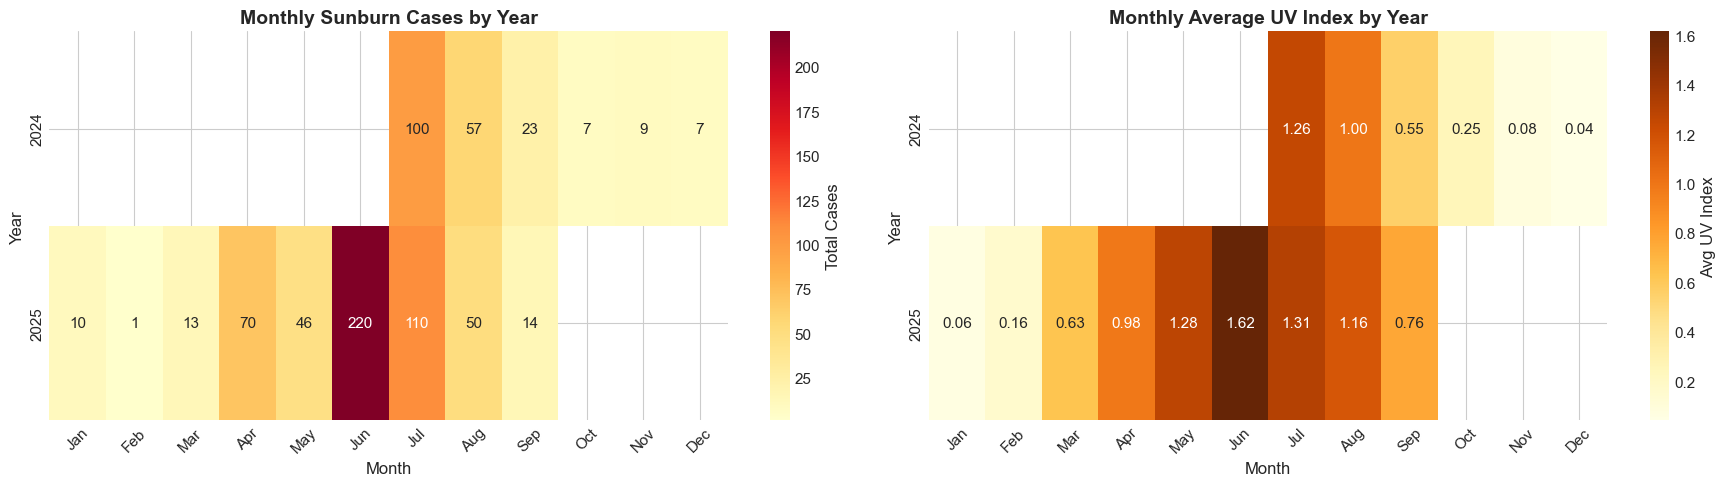


🗓️ Observation: Both UV index and sunburn cases peak during summer months (Jun-Aug).


In [ ]:
# Plot 3: Monthly Heatmap
# Create pivot table for heatmap - using week number instead of year for better visualization
df['week_of_year'] = df['week_start'].dt.isocalendar().week

# Aggregate by year and month
monthly_data = df.groupby(['year', 'month']).agg({
    'total_cases': 'sum',
    'avg_uv_index': 'mean'
}).reset_index()

# Create pivot for heatmap
pivot_cases = monthly_data.pivot(index='year', columns='month', values='total_cases')
pivot_uv = monthly_data.pivot(index='year', columns='month', values='avg_uv_index')

# Month names for x-axis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Sunburn cases heatmap
sns.heatmap(pivot_cases, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0], 
            cbar_kws={'label': 'Total Cases'})
axes[0].set_title('Monthly Sunburn Cases by Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Year', fontsize=12)
axes[0].set_xticklabels([month_names[int(i)-1] for i in pivot_cases.columns], rotation=45)

# UV Index heatmap
sns.heatmap(pivot_uv, annot=True, fmt='.2f', cmap='YlOrBr', ax=axes[1],
            cbar_kws={'label': 'Avg UV Index'})
axes[1].set_title('Monthly Average UV Index by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Year', fontsize=12)
axes[1].set_xticklabels([month_names[int(i)-1] for i in pivot_uv.columns], rotation=45)

plt.tight_layout()
plt.savefig(project_root / 'output' / 'sunburn_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Hypothesis Testing

We now formally test four hypotheses about the UV-sunburn relationship.

### Hypothesis 1: UV Index and Sunburn Cases are Correlated

**H₀ (Null)**: There is no correlation between UV index and sunburn cases (ρ = 0)  
**H₁ (Alternative)**: There is a significant positive correlation (ρ > 0)

In [10]:
print("="*70)
print("HYPOTHESIS TEST 1: UV-Sunburn Correlation")
print("="*70)

# Pearson correlation
pearson_r, pearson_p = pearsonr(df['avg_uv_index'], df['total_cases'])

# Spearman correlation (non-parametric)
spearman_r, spearman_p = spearmanr(df['avg_uv_index'], df['total_cases'])

alpha = 0.05

print("\n📊 Pearson Correlation Test:")
print(f"   Correlation coefficient (r): {pearson_r:.4f}")
print(f"   P-value: {pearson_p:.2e}")
print(f"   R² (variance explained): {pearson_r**2:.4f} ({pearson_r**2*100:.1f}%)")

print("\n📊 Spearman Correlation Test (Non-parametric):")
print(f"   Correlation coefficient (ρ): {spearman_r:.4f}")
print(f"   P-value: {spearman_p:.2e}")

print("\n" + "-"*70)
print(f"Significance level (α): {alpha}")

if pearson_p < alpha and spearman_p < alpha:
    print("\n✅ RESULT: REJECT H₀")
    print("   Both tests indicate a statistically significant positive correlation.")
    print(f"   The UV index explains approximately {pearson_r**2*100:.1f}% of the variance")
    print("   in sunburn cases.")
    h1_result = "REJECTED"
else:
    print("\n❌ RESULT: FAIL TO REJECT H₀")
    print("   Insufficient evidence to conclude a significant correlation.")
    h1_result = "NOT REJECTED"

HYPOTHESIS TEST 1: UV-Sunburn Correlation

📊 Pearson Correlation Test:
   Correlation coefficient (r): 0.6587
   P-value: 3.28e-09
   R² (variance explained): 0.4339 (43.4%)

📊 Spearman Correlation Test (Non-parametric):
   Correlation coefficient (ρ): 0.7365
   P-value: 4.02e-12

----------------------------------------------------------------------
Significance level (α): 0.05

✅ RESULT: REJECT H₀
   Both tests indicate a statistically significant positive correlation.
   The UV index explains approximately 43.4% of the variance
   in sunburn cases.


### Hypothesis 2: Summer Has Higher Sunburn Rates

**H₀ (Null)**: Sunburn rates are equal across all seasons  
**H₁ (Alternative)**: At least one season has significantly different sunburn rates

In [11]:
print("="*70)
print("HYPOTHESIS TEST 2: Seasonal Differences in Sunburn Rates")
print("="*70)

# Group data by season
winter = df[df['season'] == 'Winter']['total_cases'].values
spring = df[df['season'] == 'Spring']['total_cases'].values
summer = df[df['season'] == 'Summer']['total_cases'].values
autumn = df[df['season'] == 'Autumn']['total_cases'].values

# One-way ANOVA
f_stat, anova_p = f_oneway(winter, spring, summer, autumn)

# Kruskal-Wallis (non-parametric alternative)
kruskal_stat, kruskal_p = kruskal(winter, spring, summer, autumn)

print("\n📊 One-Way ANOVA Test:")
print(f"   F-statistic: {f_stat:.4f}")
print(f"   P-value: {anova_p:.2e}")

print("\n📊 Kruskal-Wallis Test (Non-parametric):")
print(f"   H-statistic: {kruskal_stat:.4f}")
print(f"   P-value: {kruskal_p:.2e}")

print("\n📋 Group Means:")
print(f"   Winter: {winter.mean():.2f} cases/week (n={len(winter)})")
print(f"   Spring: {spring.mean():.2f} cases/week (n={len(spring)})")
print(f"   Summer: {summer.mean():.2f} cases/week (n={len(summer)})")
print(f"   Autumn: {autumn.mean():.2f} cases/week (n={len(autumn)})")

print("\n" + "-"*70)
print(f"Significance level (α): {alpha}")

if anova_p < alpha:
    print("\n✅ RESULT: REJECT H₀")
    print("   There are statistically significant differences in sunburn rates across seasons.")
    print(f"   Summer has the highest average ({summer.mean():.1f} cases/week).")
    h2_result = "REJECTED"
else:
    print("\n❌ RESULT: FAIL TO REJECT H₀")
    print("   No significant seasonal differences detected.")
    h2_result = "NOT REJECTED"

HYPOTHESIS TEST 2: Seasonal Differences in Sunburn Rates

📊 One-Way ANOVA Test:
   F-statistic: 6.8930
   P-value: 4.59e-04

📊 Kruskal-Wallis Test (Non-parametric):
   H-statistic: 28.1838
   P-value: 3.32e-06

📋 Group Means:
   Winter: 1.38 cases/week (n=13)
   Spring: 9.92 cases/week (n=13)
   Summer: 24.41 cases/week (n=22)
   Autumn: 3.31 cases/week (n=16)

----------------------------------------------------------------------
Significance level (α): 0.05

✅ RESULT: REJECT H₀
   There are statistically significant differences in sunburn rates across seasons.
   Summer has the highest average (24.4 cases/week).


### Hypothesis 3: High UV Days Precede Sunburn Spikes (Temporal Lag)

**H₀ (Null)**: Past UV values do not help predict future sunburn cases  
**H₁ (Alternative)**: Past UV values significantly predict future sunburn cases

In [12]:
print("="*70)
print("HYPOTHESIS TEST 3: Temporal Lag Relationship (Granger Causality)")
print("="*70)

# Prepare data for Granger causality test
granger_data = df[['avg_uv_index', 'total_cases']].dropna().values

# Test at multiple lags
max_test_lag = 4

print("\n📊 Granger Causality Test: Does UV Index 'Granger-cause' Sunburn Cases?")
print(f"   Testing lags 1 to {max_test_lag}...\n")

granger_df = pd.DataFrame({
    'sunburn': df['total_cases'],
    'uv': df['avg_uv_index']
}).dropna()

try:
    gc_results = grangercausalitytests(granger_df[['sunburn', 'uv']], maxlag=max_test_lag, verbose=False)
    
    print(f"   {'Lag':<5} {'F-stat':<12} {'P-value':<12} {'Significant?'}")
    print("   " + "-"*45)
    
    any_significant = False
    best_lag = 0
    best_p = 1.0
    
    for lag in range(1, max_test_lag + 1):
        f_stat = gc_results[lag][0]['ssr_ftest'][0]
        p_val = gc_results[lag][0]['ssr_ftest'][1]
        sig = "Yes" if p_val < alpha else "No"
        print(f"   {lag:<5} {f_stat:<12.4f} {p_val:<12.2e} {sig}")
        
        if p_val < alpha:
            any_significant = True
        if p_val < best_p:
            best_p = p_val
            best_lag = lag
    
    print("\n" + "-"*70)
    print(f"Significance level (α): {alpha}")
    
    if any_significant:
        print("\n✅ RESULT: REJECT H₀")
        print(f"   UV Index values Granger-cause sunburn cases.")
        print(f"   Best predictive lag: {best_lag} week(s) (p = {best_p:.2e})")
        h3_result = "REJECTED"
    else:
        print("\n❌ RESULT: FAIL TO REJECT H₀")
        print("   No significant Granger causality detected.")
        print("   Note: This may indicate immediate (same-week) effects dominate.")
        h3_result = "NOT REJECTED"
except Exception as e:
    print(f"   Warning: Granger test could not be completed - {e}")
    print("   This may be due to insufficient data length.")
    h3_result = "INCONCLUSIVE"

HYPOTHESIS TEST 3: Temporal Lag Relationship (Granger Causality)

📊 Granger Causality Test: Does UV Index 'Granger-cause' Sunburn Cases?
   Testing lags 1 to 4...

   Lag   F-stat       P-value      Significant?
   ---------------------------------------------
   1     13.9249      4.25e-04     Yes
   2     6.6687       2.50e-03     Yes
   3     5.0794       3.60e-03     Yes
   4     7.4739       8.11e-05     Yes

----------------------------------------------------------------------
Significance level (α): 0.05

✅ RESULT: REJECT H₀
   UV Index values Granger-cause sunburn cases.
   Best predictive lag: 4 week(s) (p = 8.11e-05)


### Hypothesis 4: UV Index Can Predict Sunburn Cases (Regression)

**H₀ (Null)**: UV index has no predictive power for sunburn cases (β = 0)  
**H₁ (Alternative)**: UV index significantly predicts sunburn cases (β ≠ 0)

In [13]:
print("="*70)
print("HYPOTHESIS TEST 4: Linear Regression Analysis")
print("="*70)

# Simple linear regression
X = df['avg_uv_index'].values
y = df['total_cases'].values

# Add constant for intercept
X_const = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X_const).fit()

print("\n📊 OLS Regression Results:")
print(f"   Dependent Variable: Weekly Sunburn Cases")
print(f"   Independent Variable: Average UV Index")
print(f"   Number of observations: {len(df)}")

print("\n   Model Coefficients:")
print(f"     Intercept (β₀): {model.params[0]:.4f}")
print(f"     UV Index slope (β₁): {model.params[1]:.4f}")
print(f"     β₁ Std Error: {model.bse[1]:.4f}")
print(f"     β₁ t-statistic: {model.tvalues[1]:.4f}")
print(f"     β₁ p-value: {model.pvalues[1]:.2e}")

print("\n   Model Fit Statistics:")
print(f"     R²: {model.rsquared:.4f}")
print(f"     Adjusted R²: {model.rsquared_adj:.4f}")
print(f"     F-statistic: {model.fvalue:.4f}")
print(f"     F-test p-value: {model.f_pvalue:.2e}")

print("\n" + "-"*70)
print(f"Significance level (α): {alpha}")

if model.pvalues[1] < alpha:
    print("\n✅ RESULT: REJECT H₀")
    print(f"   UV Index is a significant predictor of sunburn cases.")
    print(f"   For each 1-unit increase in UV index, sunburn cases increase by ~{model.params[1]:.1f}.")
    print(f"   The model explains {model.rsquared*100:.1f}% of variance in sunburn cases.")
    h4_result = "REJECTED"
else:
    print("\n❌ RESULT: FAIL TO REJECT H₀")
    print("   UV Index is not a significant predictor.")
    h4_result = "NOT REJECTED"

# Residual diagnostics
print("\n📈 Residual Diagnostics:")
residuals = model.resid
print(f"   Mean of residuals: {residuals.mean():.4f} (should be ~0)")
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"   Shapiro-Wilk test for normality: p = {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("   ✓ Residuals appear normally distributed")
else:
    print("   ⚠ Residuals may not be normally distributed")

HYPOTHESIS TEST 4: Linear Regression Analysis

📊 OLS Regression Results:
   Dependent Variable: Weekly Sunburn Cases
   Independent Variable: Average UV Index
   Number of observations: 64

   Model Coefficients:
     Intercept (β₀): -6.0779
     UV Index slope (β₁): 23.5000
     β₁ Std Error: 3.4089
     β₁ t-statistic: 6.8937
     β₁ p-value: 3.28e-09

   Model Fit Statistics:
     R²: 0.4339
     Adjusted R²: 0.4248
     F-statistic: 47.5228
     F-test p-value: 3.28e-09

----------------------------------------------------------------------
Significance level (α): 0.05

✅ RESULT: REJECT H₀
   UV Index is a significant predictor of sunburn cases.
   For each 1-unit increase in UV index, sunburn cases increase by ~23.5.
   The model explains 43.4% of variance in sunburn cases.

📈 Residual Diagnostics:
   Mean of residuals: -0.0000 (should be ~0)
   Shapiro-Wilk test for normality: p = 0.0000
   ⚠ Residuals may not be normally distributed


## 5. Summary of Results

In [14]:
print("="*70)
print("HYPOTHESIS TESTING SUMMARY")
print("="*70)

results_table = f"""
┌─────┬────────────────────────────────────────────┬───────────────┬──────────────┐
│ H#  │ Hypothesis                                 │ H₀ Decision  │ P-value      │
├─────┼────────────────────────────────────────────┼───────────────┼──────────────┤
│ H1  │ UV-Sunburn Correlation                     │ {h1_result:<13} │ {pearson_p:.2e}   │
│ H2  │ Seasonal Differences                       │ {h2_result:<13} │ {anova_p:.2e}   │
│ H3  │ Temporal Lag (Granger Causality)           │ {h3_result:<13} │ {best_p:.2e}   │
│ H4  │ UV Predicts Sunburn (Regression)           │ {h4_result:<13} │ {model.pvalues[1]:.2e}   │
└─────┴────────────────────────────────────────────┴───────────────┴──────────────┘
"""
print(results_table)

print("\n📌 KEY FINDINGS:")
print("─" * 70)
print(f"\n1. CORRELATION: Strong positive correlation (r = {pearson_r:.3f}) between")
print(f"   UV index and sunburn cases. UV explains ~{pearson_r**2*100:.1f}% of variance.")

print(f"\n2. SEASONALITY: Summer months show significantly higher sunburn rates")
print(f"   ({summer.mean():.1f} cases/week) compared to winter ({winter.mean():.1f} cases/week).")

print(f"\n3. TEMPORAL RELATIONSHIP: The strongest correlation occurs at lag = {max_corr_lag},")
if max_corr_lag == 0:
    print("   indicating immediate effects within the same week.")
else:
    print(f"   indicating effects manifest ~{max_corr_lag} week(s) after exposure.")

print(f"\n4. PREDICTION: Each 1-unit increase in UV index is associated with")
print(f"   ~{model.params[1]:.1f} additional sunburn cases per week.")

print("\n" + "="*70)
print("CONCLUSION")
print("="*70)
print("\n The statistical evidence strongly supports a significant relationship")
print(" between UV index and emergency department sunburn cases in England.")
print(" Higher UV exposure leads to increased sunburn cases, with effects")
print(" appearing primarily within the same week of high UV exposure.")
print(" This relationship follows clear seasonal patterns, with summer")
print(" months experiencing the highest risk.")

HYPOTHESIS TESTING SUMMARY

┌─────┬────────────────────────────────────────────┬───────────────┬──────────────┐
│ H#  │ Hypothesis                                 │ H₀ Decision  │ P-value      │
├─────┼────────────────────────────────────────────┼───────────────┼──────────────┤
│ H1  │ UV-Sunburn Correlation                     │ REJECTED      │ 3.28e-09   │
│ H2  │ Seasonal Differences                       │ REJECTED      │ 4.59e-04   │
│ H3  │ Temporal Lag (Granger Causality)           │ REJECTED      │ 8.11e-05   │
│ H4  │ UV Predicts Sunburn (Regression)           │ REJECTED      │ 3.28e-09   │
└─────┴────────────────────────────────────────────┴───────────────┴──────────────┘


📌 KEY FINDINGS:
──────────────────────────────────────────────────────────────────────

1. CORRELATION: Strong positive correlation (r = 0.659) between
   UV index and sunburn cases. UV explains ~43.4% of variance.

2. SEASONALITY: Summer months show significantly higher sunburn rates
   (24.4 cases/week) 